Data Storage and Organization
------------------------------

In [1]:
pip install polars pyarrow tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re
import polars as pl
from tqdm import tqdm

# ==========================
# USER SETTINGS (EDIT THESE)
# ==========================
RAW_ROOT = Path(r"C:\Users\wyao2\Dropbox")   # <-- root with YYYY folders
OUT_ROOT = Path(r"C:\Users\wyao2\Documents\MATH279Project")                         # <-- output root (prefer SSD)
OUT_PARQUET = OUT_ROOT / "parquet"
OUT_MANIFEST = OUT_ROOT / "manifest.csv"

YEAR_MIN = 2000
YEAR_MAX = 2023

# Keep only what you need for your proposal pipeline
# (Edit these names ONLY if your columns differ)
KEEP_COLS = [
    "PERMNO",
    "ticker",
    "pvCLCL",          # close-to-close return
    "volume",          # share volume
    "PRC",             # price
    "DLRET",           # delisting return
    "open",            # raw open price
    "close",           # raw close price
    "OPCL",            # open-to-close raw/simple return if present
    "CFACPR",          # price adjustment factor
    "CFACSHR",         # share adjustment factor
    "SICCD",           # sector / industry mapping
    "SHRCD",           # common share filter later
    "PRIMEXCH",        # exchange filter later
    # optional forward/markout return fields if present
    "fret_RR_CLCL",
    "fret_RR_CLOP",
    "fret_RR_tmOPCL",
]

FINAL_COLS = [
    "date",
    "PERMNO",
    "ticker",
    "pvCLCL",
    "volume",
    "dollar_vol",
    "PRC",
    "DLRET",
    "open",
    "close",
    "open_adj",
    "close_adj",
    "OPCL",
    "CFACPR",
    "CFACSHR",
    "SICCD",
    "SHRCD",
    "PRIMEXCH",
    "fret_RR_CLCL",
    "fret_RR_CLOP",
    "fret_RR_tmOPCL",
]

# If you want a smaller output for now, set one of these:
FILTER_COMMON_STOCKS = False  # set True only if your files include SHRCD/EXCHCD cols
COMMON_SHRCD = {10, 11}
COMMON_PRIMEXCH = {"N", "A", "Q"}

# ==========================
# HELPERS
# ==========================
def extract_yyyymmdd_from_filename(p: Path) -> str:
    m = re.search(r"(\d{8})", p.name)
    if not m:
        raise ValueError(f"Cannot parse YYYYMMDD from filename: {p.name}")
    return m.group(1)

def safe_select(df: pl.DataFrame, cols) -> pl.DataFrame:
    existing = [c for c in cols if c in df.columns]
    return df.select(existing)

def force_date_from_filename(df: pl.DataFrame, yyyymmdd: str) -> pl.DataFrame:
    df = df.with_columns(pl.lit(yyyymmdd).alias("date"))
    df = df.with_columns(pl.col("date").str.strptime(pl.Date, "%Y%m%d", strict=False))
    return df

def cast_numeric(df: pl.DataFrame) -> pl.DataFrame:
    numeric_cols = [
        "pvCLCL",
        "volume",
        "PRC",
        "DLRET",
        "open",
        "close",
        "OPCL",
        "CFACPR",
        "CFACSHR",
        "SICCD",
        "SHRCD",
        "fret_RR_CLCL",
        "fret_RR_CLOP",
        "fret_RR_tmOPCL",
    ]

    for c in numeric_cols:
        if c in df.columns:
            df = df.with_columns(pl.col(c).cast(pl.Float64, strict=False))

    if "PERMNO" in df.columns:
        df = df.with_columns(pl.col("PERMNO").cast(pl.Int64, strict=False))

    if "SICCD" in df.columns:
        df = df.with_columns(pl.col("SICCD").cast(pl.Int64, strict=False))

    if "SHRCD" in df.columns:
        df = df.with_columns(pl.col("SHRCD").cast(pl.Int64, strict=False))

    return df

def add_derived_columns(df: pl.DataFrame) -> pl.DataFrame:
    # Dollar volume for liquidity ranking
    if "PRC" in df.columns and "volume" in df.columns:
        df = df.with_columns(
            (pl.col("PRC").abs() * pl.col("volume")).alias("dollar_vol")
        )

    # Adjusted prices
    if "open" in df.columns and "close" in df.columns and "CFACPR" in df.columns:
        df = df.with_columns([
            pl.when(pl.col("CFACPR").is_not_null() & (pl.col("CFACPR") != 0))
              .then(pl.col("open") / pl.col("CFACPR"))
              .otherwise(None)
              .alias("open_adj"),

            pl.when(pl.col("CFACPR").is_not_null() & (pl.col("CFACPR") != 0))
              .then(pl.col("close") / pl.col("CFACPR"))
              .otherwise(None)
              .alias("close_adj"),
        ])

    return df

def optional_common_stock_filter(df: pl.DataFrame) -> pl.DataFrame:
    # Only works if SHRCD and PRIMEXCH exist
    if not FILTER_COMMON_STOCKS:
        return df
    if "SHRCD" in df.columns and "PRIMEXCH" in df.columns:
        return df.filter(
            pl.col("SHRCD").is_in(list(COMMON_SHRCD)) &
            pl.col("PRIMEXCH").is_in(list(COMMON_PRIMEXCH))
        )
    return df

# ==========================
# MAIN
# ==========================
OUT_PARQUET.mkdir(parents=True, exist_ok=True)
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Collect files
files = []
for y in range(YEAR_MIN, YEAR_MAX + 1):
    year_dir = RAW_ROOT / str(y)
    if not year_dir.exists():
        print(f"[WARN] Missing year folder: {year_dir}")
        continue
    # accept .csv.gz (and .csv if any)
    files.extend(sorted(year_dir.glob("*.csv.gz")))
    files.extend(sorted(year_dir.glob("*.csv")))

if not files:
    raise FileNotFoundError(f"No .csv.gz/.csv files found under {RAW_ROOT}")

print(f"Found {len(files)} daily files under {RAW_ROOT}")
print(f"Writing Parquet to {OUT_PARQUET}")

manifest_rows = []

for f in tqdm(files, desc="Reading daily files"):
    try:
        yyyymmdd = extract_yyyymmdd_from_filename(f)
        year = yyyymmdd[:4]
        month = yyyymmdd[4:6]

        df = pl.read_csv(f, infer_schema_length=2000, ignore_errors=True)

        # Skip empty/header-only files
        if df.height == 0:
            manifest_rows.append({"path": str(f), "yyyymmdd": yyyymmdd, "status": "empty"})
            continue

        # Drop common junk cols if present
        for junk in ["Unnamed: 0", ""]:
            if junk in df.columns:
                df = df.drop(junk)

        # Add/override date from filename to ensure correctness
        df = force_date_from_filename(df, yyyymmdd)

        # Optional: filter to common stocks only (if SHRCD/EXCHCD exist)
        df = optional_common_stock_filter(df)

        # Keep raw columns needed for the research pipeline
        df = safe_select(df, ["date"] + KEEP_COLS)


        # Basic sanity: require PERMNO and ticker if present
        if "PERMNO" in df.columns:
            df = df.filter(pl.col("PERMNO").is_not_null())
        if "ticker" in df.columns:
            df = df.filter(pl.col("ticker").is_not_null())
        if "date" in df.columns:
            df = df.filter(pl.col("date").is_not_null())
        if "volume" in df.columns:
            df = df.filter(pl.col("volume").is_null() | (pl.col("volume") >= 0))

        # Cast numerics for consistency
        df = cast_numeric(df)

        # Add derived columns useful for research
        df = add_derived_columns(df)

        df = df.with_columns([
            pl.lit(int(year)).alias("year"),
            pl.lit(month).alias("month"),
        ])

        # Keep final output columns in stable order
        df = safe_select(df, FINAL_COLS)


        if len(manifest_rows) < 3:
            print(f"\nSample columns for {f.name}:")
            print(df.columns)
            print(df.head(3))

        # Write partitioned parquet (year/month)
        out_dir = OUT_PARQUET / f"year={year}" / f"month={month}"
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"part-{yyyymmdd}.parquet"
        df.write_parquet(out_path, compression="zstd")

        manifest_rows.append({"path": str(f), "yyyymmdd": yyyymmdd, "status": "ok", "rows": df.height})

    except Exception as e:
        manifest_rows.append({"path": str(f), "yyyymmdd": None, "status": f"error: {e}"})

# Write manifest for debugging
manifest = pl.DataFrame(manifest_rows)
manifest.write_csv(OUT_MANIFEST)
print(f"Done. Manifest written to: {OUT_MANIFEST}")
print(f"Parquet dataset written to: {OUT_PARQUET}")

Found 6060 daily files under C:\Users\wyao2\Dropbox
Writing Parquet to C:\Users\wyao2\Documents\MATH279Project\parquet


Reading daily files:   0%|          | 0/6060 [00:00<?, ?it/s]


Sample columns for 20000103.csv.gz:
['date', 'PERMNO', 'ticker', 'pvCLCL', 'volume', 'dollar_vol', 'PRC', 'DLRET', 'open', 'close', 'open_adj', 'close_adj', 'OPCL', 'CFACPR', 'CFACSHR', 'SICCD', 'SHRCD', 'PRIMEXCH', 'fret_RR_CLCL', 'fret_RR_CLOP', 'fret_RR_tmOPCL']
shape: (3, 21)
â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”
â”‚ date       â”† PERMNO â”† ticker â”† pvCLCL    â”† â€¦ â”† PRIMEXCH â”† fret_RR_CLC â”† fret_RR_CLO â”† fret_RR_tm â”‚
â”‚ ---        â”† ---    â”† ---    â”† ---       â”†   â”† ---      â”† L           â”† P           â”† OPCL       â”‚
â”‚ date       â”† i64    â”† str    â”† f64       â”†   â”† str      â”† ---         â”† ---         â”† ---        â”‚
â”‚            â”†        â”†        â”†           â

Reading daily files:   0%|          | 2/6060 [00:01<1:33:31,  1.08it/s]


Sample columns for 20000104.csv.gz:
['date', 'PERMNO', 'ticker', 'pvCLCL', 'volume', 'dollar_vol', 'PRC', 'DLRET', 'open', 'close', 'open_adj', 'close_adj', 'OPCL', 'CFACPR', 'CFACSHR', 'SICCD', 'SHRCD', 'PRIMEXCH', 'fret_RR_CLCL', 'fret_RR_CLOP', 'fret_RR_tmOPCL']
shape: (3, 21)
â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”
â”‚ date       â”† PERMNO â”† ticker â”† pvCLCL    â”† â€¦ â”† PRIMEXCH â”† fret_RR_CLC â”† fret_RR_CLO â”† fret_RR_tm â”‚
â”‚ ---        â”† ---    â”† ---    â”† ---       â”†   â”† ---      â”† L           â”† P           â”† OPCL       â”‚
â”‚ date       â”† i64    â”† str    â”† f64       â”†   â”† str      â”† ---         â”† ---         â”† ---        â”‚
â”‚            â”†        â”†        â”†           â

Reading daily files:   0%|          | 3/6060 [00:02<1:19:22,  1.27it/s]


Sample columns for 20000105.csv.gz:
['date', 'PERMNO', 'ticker', 'pvCLCL', 'volume', 'dollar_vol', 'PRC', 'DLRET', 'open', 'close', 'open_adj', 'close_adj', 'OPCL', 'CFACPR', 'CFACSHR', 'SICCD', 'SHRCD', 'PRIMEXCH', 'fret_RR_CLCL', 'fret_RR_CLOP', 'fret_RR_tmOPCL']
shape: (3, 21)
â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”
â”‚ date       â”† PERMNO â”† ticker â”† pvCLCL    â”† â€¦ â”† PRIMEXCH â”† fret_RR_CLC â”† fret_RR_CLO â”† fret_RR_tm â”‚
â”‚ ---        â”† ---    â”† ---    â”† ---       â”†   â”† ---      â”† L           â”† P           â”† OPCL       â”‚
â”‚ date       â”† i64    â”† str    â”† f64       â”†   â”† str      â”† ---         â”† ---         â”† ---        â”‚
â”‚            â”†        â”†        â”†           â

Reading daily files: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 6060/6060 [39:37<00:00,  2.55it/s] 


Done. Manifest written to: C:\Users\wyao2\Documents\MATH279Project\manifest.csv
Parquet dataset written to: C:\Users\wyao2\Documents\MATH279Project\parquet


In [3]:
!pip install duckdb

In [5]:
import duckdb
con = duckdb.connect()

df = con.execute(r"""
  SELECT date, PERMNO, ticker, pvCLCL, volume, PRC
  FROM read_parquet('C:\\Users\\wyao2\\Documents\\MATH279Project\\parquet\\year=2023\\month=11\\*.parquet')
  LIMIT 5
""").df()

print(df)

        date  PERMNO ticker    pvCLCL      volume     PRC
0 2023-11-01   84398    SPY  0.010665  98068115.0  422.66
1 2023-11-01   88222    IWM  0.005714  44367077.0  165.46
2 2023-11-01   89730    EEM  0.009264  27879383.0   37.04
3 2023-11-01   89468    TLT  0.021611  71881743.0   85.10
4 2023-11-01   91208    USO -0.003599   4143025.0   74.75


In [4]:
df = con.execute("""
SELECT COUNT(*)
FROM read_parquet('C:\\Users\\wyao2\\Documents\\MATH279Project\\parquet\\year=2010\\month=*\\*.parquet')
""").df()

df

,count_star()
0,935606


In [ ]:
df = con.execute("""
SELECT COUNT(DISTINCT PERMNO)
FROM read_parquet('C:\\Users\\wyao2\\Documents\\MATH279Project\\parquet\\year=2010\\month=*\\*.parquet')
""").df()

df

,count(DISTINCT PERMNO)
0,3910


In [14]:
spy = con.execute("""
SELECT date, pvCLCL
FROM read_parquet('C:\\Users\\wyao2\\Documents\\MATH279Project\\parquet\\year=*\\month=*\\*.parquet')
WHERE ticker='SPY'
ORDER BY date
""").df()

spy.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,date,pvCLCL
0,2000-01-03,-0.009787
1,2000-01-04,-0.039106
2,2000-01-05,0.001789
3,2000-01-06,-0.016071
4,2000-01-07,0.058076


In [5]:
con.execute("""
SELECT COUNT(DISTINCT date)
FROM read_parquet('C:\\Users\\wyao2\\Documents\\MATH279Project\\parquet\\year=*\\month=*\\*.parquet')
""").df()


,count(DISTINCT date)
0,5282


In [6]:
con.execute("""
SELECT MIN(date), MAX(date)
FROM read_parquet('C:\\Users\\wyao2\\Documents\\MATH279Project\\parquet\\year=*\\month=*\\*.parquet')
""").df()

,min(date),max(date)
0,2000-01-03,2023-12-29


Research Setup
--------------------

In [2]:
!pip install duckdb
import duckdb
import pandas as pd
import numpy as np
import os

PARQ_GLOB = r"C:\Users\wyao2\Documents\MATH279Project\parquet\year=*\month=*\*.parquet"
OUT_DIR = r"C:\Users\wyao2\Documents\MATH279Project\crsp_outputs_final"
os.makedirs(OUT_DIR, exist_ok=True)

TOP_N = 2000
ETF_TICKERS = ["SPY", "QQQ", "IWM", "TLT", "GLD", "XLF", "XLK", "XLE", "XLY", "XLV"]

con = duckdb.connect()

In [3]:
cols = con.execute(f"""
DESCRIBE
SELECT * FROM read_parquet('{PARQ_GLOB}')
""").df()

cols

,column_name,column_type,null,key,default,extra
0,date,DATE,YES,None,None,None
1,PERMNO,BIGINT,YES,None,None,None
2,ticker,VARCHAR,YES,None,None,None
3,pvCLCL,DOUBLE,YES,None,None,None
4,volume,DOUBLE,YES,None,None,None
5,dollar_vol,DOUBLE,YES,None,None,None
6,PRC,DOUBLE,YES,None,None,None
7,DLRET,DOUBLE,YES,None,None,None
8,open,DOUBLE,YES,None,None,None
9,close,DOUBLE,YES,None,None,None


In [4]:
etf_list_sql = ",".join([f"'{t}'" for t in ETF_TICKERS])

universe = con.execute(f"""
WITH base AS (
    SELECT
        PERMNO,
        MAX(ticker) AS ticker,
        MAX(SICCD) AS SICCD,
        MAX(SHRCD) AS SHRCD,
        MAX(PRIMEXCH) AS PRIMEXCH,
        AVG(dollar_vol) AS avg_dollar_vol
    FROM read_parquet('{PARQ_GLOB}')
    WHERE dollar_vol IS NOT NULL
      AND dollar_vol > 0
      AND PERMNO IS NOT NULL
      AND ticker IS NOT NULL
      AND ticker NOT IN ({etf_list_sql})
      AND SHRCD IN (10, 11)
      AND PRIMEXCH IN ('N', 'A', 'Q')
    GROUP BY PERMNO
)
SELECT *
FROM base
ORDER BY avg_dollar_vol DESC
LIMIT {TOP_N}
""").df()

print(universe.shape)
universe.head()

(2000, 6)


,PERMNO,ticker,SICCD,SHRCD,PRIMEXCH,avg_dollar_vol
0,93436,TSLA,9999,11,Q,7.672951e+09
1,14593,AAPL,3573,11,Q,5.469883e+09
2,13407,META,7375,11,Q,3.880295e+09
3,84788,AMZN,7370,11,Q,3.099661e+09
4,10107,MSFT,7370,11,Q,2.934284e+09


In [5]:
permnos = universe["PERMNO"].astype(int).tolist()
permno_sql = ",".join(map(str, permnos))

df = con.execute(f"""
SELECT
    date,
    PERMNO,
    ticker,
    volume,
    open_adj,
    close_adj,
    SICCD,
    SHRCD,
    PRIMEXCH
FROM read_parquet('{PARQ_GLOB}')
WHERE PERMNO IN ({permno_sql})
  AND date IS NOT NULL
ORDER BY date, PERMNO
""").df()

print(df.shape)
print(df.columns.tolist())
df.head()

(6815053, 9)
['date', 'PERMNO', 'ticker', 'volume', 'open_adj', 'close_adj', 'SICCD', 'SHRCD', 'PRIMEXCH']


,date,PERMNO,ticker,volume,open_adj,close_adj,SICCD,SHRCD,PRIMEXCH
0,2000-01-03,10104,ORCL,24831819.0,31.155,29.530,7370,11,Q
1,2000-01-03,10107,MSFT,26937123.0,58.690,58.280,7370,11,Q
2,2000-01-03,10108,SDS,506900.0,11.875,12.375,7374,11,N
3,2000-01-03,10137,AYE,188800.0,27.120,25.940,4911,11,N
4,2000-01-03,10138,TROW,381616.0,18.530,17.560,6210,11,Q


### Return decomposition from adjusted prices

To avoid timing ambiguities in vendor-provided return columns,
returns are reconstructed directly from adjusted open and close prices.

Definitions:

CC_t = log(close_t / close_{t-1})  
CO_t = log(open_t / close_{t-1})  
OC_t = log(close_t / open_t)

In [15]:
# =========================================================
# BUILD RETURN PANELS FROM ADJUSTED PRICES
# =========================================================

# pivot price panels
close_panel = df.pivot(index="date", columns="PERMNO", values="close_adj")
open_panel  = df.pivot(index="date", columns="PERMNO", values="open_adj")

close_panel = close_panel.sort_index()
open_panel  = open_panel.sort_index()

# log prices
log_close = np.log(close_panel)
log_open  = np.log(open_panel)

# return decomposition
ret_cc = log_close - log_close.shift(1)
ret_co = log_open  - log_close.shift(1)
ret_oc = log_close - log_open

print("Return panels created")
print(ret_cc.shape)

# =========================================================
# BUILD VOLUME PANEL
# =========================================================

vol = df.pivot(index="date", columns="PERMNO", values="volume")
vol = vol.sort_index()

print("Volume panel created")
print(vol.shape)
display(vol.head())

Return panels created
(6035, 2000)
Volume panel created
(6035, 2000)


PERMNO,10104,10107,10108,10137,10138,10145,10147,10200,10220,10225,...,93312,93330,93369,93373,93374,93420,93422,93423,93429,93436
date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,24831819.0,26937123.0,506900.0,188800.0,381616.0,2100799.0,9519399.0,132552.0,NaN,332600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,29568565.0,27531141.0,1043300.0,235300.0,545646.0,2670299.0,7576599.0,60900.0,NaN,289000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,42032160.0,32708345.0,1155699.0,267800.0,535862.0,2975699.0,10195399.0,89150.0,NaN,221000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,27848885.0,27997348.0,1358000.0,160800.0,252966.0,2388000.0,5577899.0,125779.0,NaN,510600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,23218034.0,31415665.0,1296199.0,338400.0,237955.0,3943399.0,6222399.0,175983.0,NaN,315400.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# =========================================================
# VERIFY RETURN DECOMPOSITION
# =========================================================

lhs = ret_cc.stack().rename("cc")
rhs = (ret_co + ret_oc).stack().rename("co_plus_oc")

aligned = pd.concat([lhs, rhs], axis=1).dropna()

print("Correlation:", aligned["cc"].corr(aligned["co_plus_oc"]))
print("Mean absolute error:", np.mean(np.abs(aligned["cc"] - aligned["co_plus_oc"])))

Correlation: 1.0
Mean absolute error: 1.9929478540778214e-21


In [19]:


check = (ret_cc - (ret_co + ret_oc)).stack().dropna()

print("mean abs decomposition error:", check.abs().mean())
print("median abs decomposition error:", check.abs().median())
print("max abs decomposition error:", check.abs().max())

mean abs decomposition error: 1.9929478540778214e-21
median abs decomposition error: 0.0
max abs decomposition error: 2.220446049250313e-16


In [20]:
stock_meta = universe[["PERMNO", "ticker", "SICCD", "SHRCD", "PRIMEXCH"]].copy()
stock_meta.head()

,PERMNO,ticker,SICCD,SHRCD,PRIMEXCH
0,93436,TSLA,9999,11,Q
1,14593,AAPL,3573,11,Q
2,13407,META,7375,11,Q
3,84788,AMZN,7370,11,Q
4,10107,MSFT,7370,11,Q


In [21]:
etf = con.execute(f"""
SELECT
    date,
    ticker,
    open_adj,
    close_adj
FROM read_parquet('{PARQ_GLOB}')
WHERE ticker IN ({etf_list_sql})
  AND date IS NOT NULL
ORDER BY date, ticker
""").df()

print(etf["ticker"].value_counts())
etf.head()

ticker
SPY    6035
XLE    6035
XLF    6035
XLK    6035
XLV    6035
XLY    6035
IWM    5933
TLT    5392
GLD    4808
QQQ    4445
Name: count, dtype: int64


,date,ticker,open_adj,close_adj
0,2000-01-03,QQQ,96.190000,94.750000
1,2000-01-03,SPY,148.250000,145.440000
2,2000-01-03,XLE,27.310000,26.560000
3,2000-01-03,XLF,19.248325,18.566681
4,2000-01-03,XLK,55.620000,55.440000


In [22]:
# =========================================================
# BUILD ETF RETURN PANELS FROM ADJUSTED PRICES
# =========================================================

etf = etf.sort_values(["date", "ticker"]).copy()

etf_close_panel = etf.pivot(index="date", columns="ticker", values="close_adj").sort_index()
etf_open_panel  = etf.pivot(index="date", columns="ticker", values="open_adj").sort_index()

etf_log_close = np.log(etf_close_panel)
etf_log_open = np.log(etf_open_panel)

etf_ret_cc = etf_log_close - etf_log_close.shift(1)
etf_ret_co = etf_log_open - etf_log_close.shift(1)
etf_ret_oc = etf_log_close - etf_log_open

# align ETF calendar to stock calendar
etf_ret_cc = etf_ret_cc.reindex(ret_cc.index)
etf_ret_co = etf_ret_co.reindex(ret_cc.index)
etf_ret_oc = etf_ret_oc.reindex(ret_cc.index)

print("etf_ret_cc:", etf_ret_cc.shape)
print("etf_ret_co:", etf_ret_co.shape)
print("etf_ret_oc:", etf_ret_oc.shape)

etf_ret_cc: (6035, 10)
etf_ret_co: (6035, 10)
etf_ret_oc: (6035, 10)


In [23]:
lhs_etf = etf_ret_cc.stack().rename("cc")
rhs_etf = (etf_ret_co + etf_ret_oc).stack().rename("co_plus_oc")

aligned_etf = pd.concat([lhs_etf, rhs_etf], axis=1).dropna()

print("ETF decomposition correlation:", aligned_etf["cc"].corr(aligned_etf["co_plus_oc"]))
print("ETF mean abs error:", np.mean(np.abs(aligned_etf["cc"] - aligned_etf["co_plus_oc"])))

ETF decomposition correlation: 1.0
ETF mean abs error: 0.0


In [24]:

OUT_DIR = r"C:\Users\wyao2\Documents\MATH279Project\crsp_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

for df_obj in [ret_cc, ret_co, ret_oc, vol]:
    df_obj.columns = df_obj.columns.astype(str)

for df_obj in [etf_ret_cc, etf_ret_co, etf_ret_oc]:
    df_obj.columns = df_obj.columns.astype(str)

ret_cc.to_parquet(os.path.join(OUT_DIR, "ret_cc_top2000.parquet"))
ret_co.to_parquet(os.path.join(OUT_DIR, "ret_co_top2000.parquet"))
ret_oc.to_parquet(os.path.join(OUT_DIR, "ret_oc_top2000.parquet"))
vol.to_parquet(os.path.join(OUT_DIR, "vol_top2000.parquet"))

etf_ret_cc.to_parquet(os.path.join(OUT_DIR, "etf_ret_cc_10.parquet"))
etf_ret_co.to_parquet(os.path.join(OUT_DIR, "etf_ret_co_10.parquet"))
etf_ret_oc.to_parquet(os.path.join(OUT_DIR, "etf_ret_oc_10.parquet"))

universe.to_csv(os.path.join(OUT_DIR, "universe_top2000.csv"), index=False)
stock_meta.to_csv(os.path.join(OUT_DIR, "stock_meta_top2000.csv"), index=False)

pd.DataFrame({"ticker": ETF_TICKERS}).to_csv(
    os.path.join(OUT_DIR, "etf_universe_10.csv"), index=False
)

print("Saved final baseline dataset successfully.")

Saved final baseline dataset successfully.


In [25]:
print("Universe rows:", len(universe))
print("Unique stock PERMNOs:", universe["PERMNO"].nunique())
print("Any ETF ticker in stock universe?:", universe["ticker"].isin(ETF_TICKERS).any())

print("ret_cc:", ret_cc.shape)
print("ret_co:", ret_co.shape)
print("ret_oc:", ret_oc.shape)
print("vol:", vol.shape)

print("etf_ret_cc:", etf_ret_cc.shape)
print("etf_ret_co:", etf_ret_co.shape)
print("etf_ret_oc:", etf_ret_oc.shape)

print("\nETF non-missing counts (cc):")
print(etf_ret_cc.notna().sum())

Universe rows: 2000
Unique stock PERMNOs: 2000
Any ETF ticker in stock universe?: False
ret_cc: (6035, 2000)
ret_co: (6035, 2000)
ret_oc: (6035, 2000)
vol: (6035, 2000)
etf_ret_cc: (6035, 10)
etf_ret_co: (6035, 10)
etf_ret_oc: (6035, 10)

ETF non-missing counts (cc):
ticker
GLD    4807
IWM    5932
QQQ    4443
SPY    6034
TLT    5391
XLE    6034
XLF    6034
XLK    6034
XLV    6034
XLY    6034
dtype: int64


Core Research: CC Benchmark with Market-Wide Synchronization
------------------------------------------------------------

This section is the canonical benchmark for the project.

It keeps the empirical design centered on:

- stock close-to-close (`CC`) returns as the target,
- ETF close-to-close (`CC`) returns as the predictor,
- synchronization built from the full stock universe,
- pooled OLS with stock HAR controls, ETF HAR predictors, and synchronization interactions.

The later sections are follow-on extensions:

1. Extension 1 studies when the benchmark effect appears by decomposing returns into `CO` and `OC`.
2. Extension 2 studies whether the benchmark effect sharpens when synchronization is measured on ETF-matched stock universes.

### Benchmark synchronization from the full stock universe

In [26]:
import numpy as np
import pandas as pd

ROLL_WIN = 60
TAU = 2.0
HIGH_Q = 0.80
EPS = 1e-12

# Ensure sorted index
vol = vol.sort_index()
ret_cc = ret_cc.sort_index()
ret_co = ret_co.sort_index()
ret_oc = ret_oc.sort_index()


def build_sync_measure(vol_panel, member_cols=None, roll_win=ROLL_WIN, tau=TAU, high_q=HIGH_Q, eps=EPS, label="sync"):
    """
    Build a synchronization index and high-sync regime from a selected stock universe.
    """
    panel = vol_panel.sort_index()

    if member_cols is None:
        member_cols = panel.columns.tolist()
    else:
        member_cols = [str(col) for col in member_cols if str(col) in panel.columns]

    if len(member_cols) == 0:
        raise ValueError(f"No valid stock columns available for synchronization label={label}.")

    subvol = panel.loc[:, member_cols]
    mu_vol = subvol.rolling(roll_win, min_periods=roll_win).mean().shift(1)
    sd_vol = subvol.rolling(roll_win, min_periods=roll_win).std(ddof=0).shift(1)

    z_vol = (subvol - mu_vol) / (sd_vol + eps)
    z_tilde = z_vol.where(z_vol.abs() > tau, 0.0)

    sync_idx = (z_tilde ** 2).sum(axis=1)
    sync_idx.name = f"sync_idx_{label}"

    sync_thresh = sync_idx.quantile(high_q)
    high_sync = (sync_idx > sync_thresh).astype(int)
    high_sync.name = f"high_sync_{label}"

    high_sync_l1 = high_sync.shift(1)
    high_sync_l1.name = f"high_sync_{label}_l1"

    return {
        "member_cols": member_cols,
        "mu_vol": mu_vol,
        "sd_vol": sd_vol,
        "z_vol": z_vol,
        "z_tilde": z_tilde,
        "sync_idx": sync_idx,
        "sync_thresh": sync_thresh,
        "high_sync": high_sync,
        "high_sync_l1": high_sync_l1,
    }


market_sync = build_sync_measure(vol, label="market")
mu_vol = market_sync["mu_vol"]
sd_vol = market_sync["sd_vol"]
z_vol = market_sync["z_vol"]
z_tilde = market_sync["z_tilde"]
sync_idx = market_sync["sync_idx"].rename("sync_idx")
sync_thresh = market_sync["sync_thresh"]
high_sync = market_sync["high_sync"].rename("high_sync")
high_sync_l1 = market_sync["high_sync_l1"].rename("high_sync_l1")

print(sync_idx.describe())
print("High-sync threshold:", sync_thresh)
print("High-sync share:", high_sync.mean())

count    6.035000e+03
mean     3.593694e+03
std      5.522047e+04
min      0.000000e+00
25%      7.749637e+02
50%      1.425909e+03
75%      2.682535e+03
max      3.888469e+06
Name: sync_idx, dtype: float64
High-sync threshold: 3109.417034638739
High-sync share: 0.2


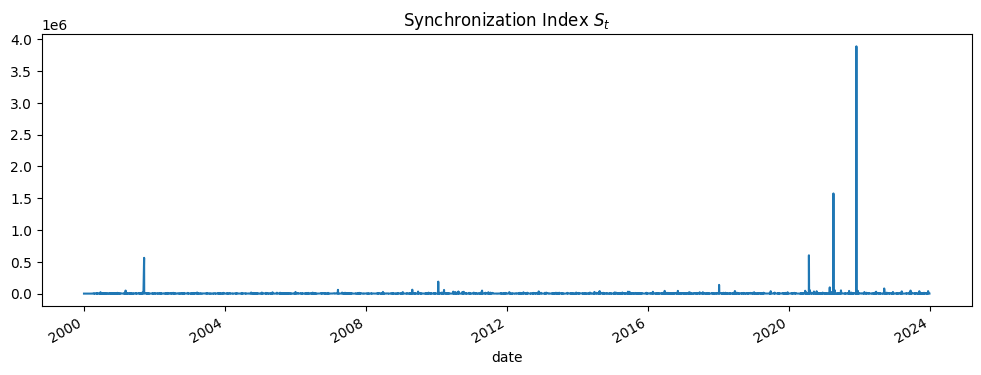

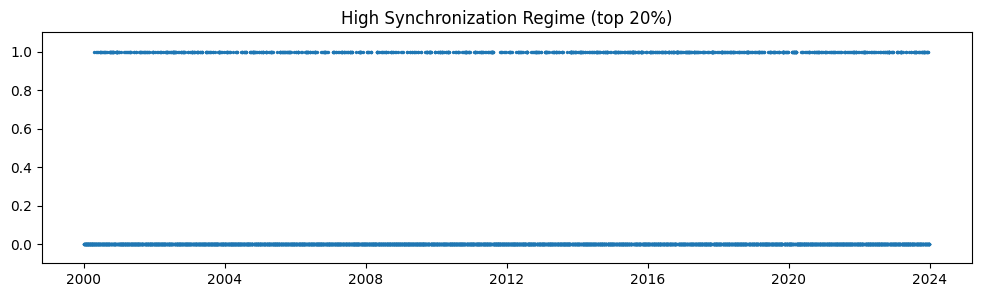

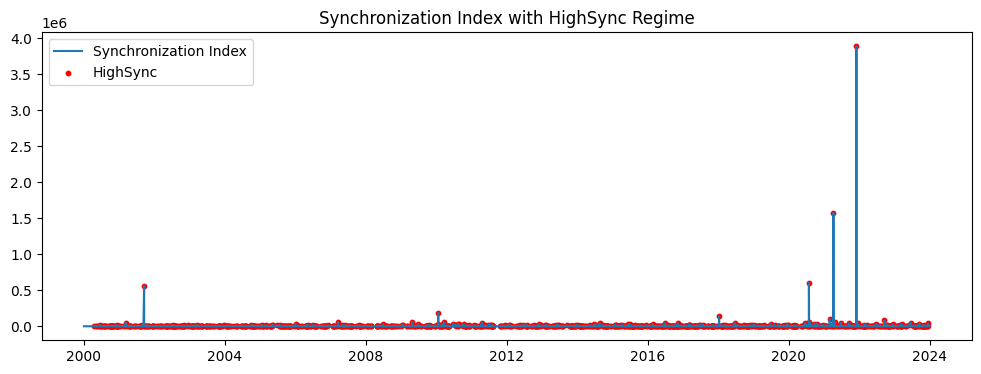

In [27]:
import matplotlib.pyplot as plt

sync_idx.plot(title="Synchronization Index $S_t$", figsize=(12, 4))
plt.show()

plt.figure(figsize=(12, 3))
plt.scatter(high_sync.index, high_sync, s=2)
plt.title("High Synchronization Regime (top 20%)")
plt.ylim(-0.1, 1.1)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sync_idx, label="Synchronization Index")
plt.scatter(sync_idx.index[high_sync == 1], sync_idx[high_sync == 1], color="red", s=10, label="HighSync")
plt.legend()
plt.title("Synchronization Index with HighSync Regime")
plt.show()

In [28]:
#Dates with highest activity synchronization
sync_idx.sort_values(ascending=False).head(10)

date
2021-12-02    3.888469e+06
2021-04-08    1.574728e+06
2020-07-28    6.022379e+05
2001-09-17    5.624021e+05
2010-01-21    1.881479e+05
2018-01-09    1.368612e+05
2021-03-01    9.781294e+04
2022-09-16    8.046928e+04
2009-04-27    6.129832e+04
2007-03-19    5.926939e+04
Name: sync_idx, dtype: float64

### HAR features for the benchmark CC specification

We construct heterogeneous autoregressive (HAR) predictors at three horizons:

- **Daily:** $x^d_{t-1} = x_{t-1}$
- **Weekly:** $x^w_{t-1} = \frac{1}{5}\sum_{k=1}^{5} x_{t-k}$
- **Monthly:** $x^m_{t-1} = \frac{1}{22}\sum_{k=1}^{22} x_{t-k}$

These predictors are built for all three return definitions:

- close-to-close $r^{cc}$,
- close-to-open $r^{co}$,
- open-to-close $r^{oc}$.

The benchmark in this section uses the `CC` panels. The `CO` and `OC` panels are retained for Extension 1 below.

In [29]:
def make_har_panel(panel: pd.DataFrame):
    """
    Build HAR-style lagged features for a panel indexed by date.
    Returns:
        x_d = lag-1 daily value
        x_w = lagged 5-day average
        x_m = lagged 22-day average
    """
    panel = panel.sort_index()
    x_d = panel.shift(1)
    x_w = panel.rolling(5, min_periods=5).mean().shift(1)
    x_m = panel.rolling(22, min_periods=22).mean().shift(1)
    return x_d, x_w, x_m

# HAR controls for stock returns
ret_cc_d, ret_cc_w, ret_cc_m = make_har_panel(ret_cc)
ret_co_d, ret_co_w, ret_co_m = make_har_panel(ret_co)
ret_oc_d, ret_oc_w, ret_oc_m = make_har_panel(ret_oc)

print("Built HAR stock features for CC, CO, and OC.")

Built HAR stock features for CC, CO, and OC.


### Benchmark ETF HAR predictors and market-wide synchronization interactions

The core benchmark uses ETF close-to-close returns as predictors.
For each ETF $j$, we build daily, weekly, and monthly HAR features and interact them with the lagged market-wide high-synchronization indicator $\mathbf{1}\{S^{mkt}_{t-1}>c\}$.

This is the baseline test of whether ETF-based predictability strengthens, weakens, or flips sign when the full stock market is in a high-synchronization state.

In [30]:
# Align ETF calendar to stock calendar
etf_ret_cc = etf_ret_cc.reindex(ret_cc.index)


def build_regime_interactions(etf_d, etf_w, etf_m, regime_l1):
    """
    Interact ETF HAR predictors with a lagged regime indicator.
    Works with either a common market-wide regime or ETF-specific matched regimes.
    """
    return (
        etf_d.mul(regime_l1, axis=0),
        etf_w.mul(regime_l1, axis=0),
        etf_m.mul(regime_l1, axis=0),
    )


# Build HAR ETF predictors using close-to-close ETF returns
etf_cc_d, etf_cc_w, etf_cc_m = make_har_panel(etf_ret_cc)

# Benchmark market-wide interactions
etf_cc_d_high, etf_cc_w_high, etf_cc_m_high = build_regime_interactions(
    etf_cc_d,
    etf_cc_w,
    etf_cc_m,
    high_sync_l1,
)

print("ETF panel shape:", etf_ret_cc.shape)
print("Number of ETF predictors:", etf_ret_cc.shape[1])

pd.concat(
    [
        high_sync_l1.rename("high_sync_l1"),
        etf_cc_d.iloc[:, :5].add_suffix("_d"),
        etf_cc_w.iloc[:, :5].add_suffix("_w"),
        etf_cc_m.iloc[:, :5].add_suffix("_m"),
    ],
    axis=1,
).head(10)

ETF panel shape: (6035, 10)
Number of ETF predictors: 10


,high_sync_l1,GLD_d,IWM_d,QQQ_d,SPY_d,TLT_d,GLD_w,IWM_w,QQQ_w,SPY_w,TLT_w,GLD_m,IWM_m,QQQ_m,SPY_m,TLT_m
date,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,0.0,NaN,NaN,-0.073791,-0.039909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,0.0,NaN,NaN,-0.020896,0.001787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,0.0,NaN,NaN,-0.065196,-0.016202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-10,0.0,NaN,NaN,0.091645,0.056452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-11,0.0,NaN,NaN,0.041500,0.003425,NaN,NaN,NaN,-0.005348,0.001111,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-12,0.0,NaN,NaN,-0.044329,-0.013354,NaN,NaN,NaN,0.000545,0.006422,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-13,0.0,NaN,NaN,-0.019336,-0.008700,NaN,NaN,NaN,0.000857,0.004324,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# =========================================================
# REGIME INTERACTIONS ARE PARAMETERIZED FOR LATER EXTENSIONS
# =========================================================

print("Defined reusable regime-interaction helper for benchmark and matched-sync runs.")

Built high-sync interactions for ETF CO/OC HAR features.


### Benchmark pooled CC regression

We estimate pooled OLS across stock-day observations. For each stock close-to-close return $y_{i,t}^{cc}$, the regression includes:

1. the stock's own `CC` HAR controls,
2. one ETF's `CC` HAR predictors,
3. interaction terms between the ETF HAR predictors and the lagged market-wide high-sync regime.

This is the core research specification and its output is the canonical benchmark result table.

In [46]:
def pooled_ols_single_etf_with_se(
    y_panel,
    own_d, own_w, own_m,
    etf_d, etf_w, etf_m,
    etf_d_high, etf_w_high, etf_m_high,
):
    K = 10  # const + 3 own + 3 etf + 3 interactions

    XtX = np.zeros((K, K))
    Xty = np.zeros(K)
    nobs = 0

    store_X = []
    store_y = []

    dates = y_panel.index
    stock_cols = y_panel.columns

    for t in dates:
        y = y_panel.loc[t, stock_cols].to_numpy(dtype=float)
        x_d = own_d.loc[t, stock_cols].to_numpy(dtype=float)
        x_w = own_w.loc[t, stock_cols].to_numpy(dtype=float)
        x_m = own_m.loc[t, stock_cols].to_numpy(dtype=float)

        fd  = etf_d.loc[t]
        fw  = etf_w.loc[t]
        fm  = etf_m.loc[t]
        fdh = etf_d_high.loc[t]
        fwh = etf_w_high.loc[t]
        fmh = etf_m_high.loc[t]

        valid = np.isfinite(y) & np.isfinite(x_d) & np.isfinite(x_w) & np.isfinite(x_m)
        if not valid.any():
            continue

        yv = y[valid]
        n = len(yv)

        X = np.empty((n, K))
        X[:, 0] = 1.0
        X[:, 1] = x_d[valid]
        X[:, 2] = x_w[valid]
        X[:, 3] = x_m[valid]
        X[:, 4] = fd
        X[:, 5] = fw
        X[:, 6] = fm
        X[:, 7] = fdh
        X[:, 8] = fwh
        X[:, 9] = fmh

        row_valid = np.isfinite(X).all(axis=1)
        X = X[row_valid]
        yv = yv[row_valid]

        if len(yv) == 0:
            continue

        XtX += X.T @ X
        Xty += X.T @ yv
        nobs += len(yv)

        store_X.append(X)
        store_y.append(yv)

    if nobs == 0:
        return None, 0

    try:
        beta = np.linalg.solve(XtX, Xty)
    except np.linalg.LinAlgError:
        print("Singular matrix for ETF:", etf)
        return None, 0
        
        

    # ---------- robust variance ----------
    XtX_inv = np.linalg.inv(XtX)
    meat = np.zeros((K, K))

    for X, yv in zip(store_X, store_y):
        u = yv - X @ beta
        Xu = X * u[:, None]
        meat += Xu.T @ Xu

    vcov = XtX_inv @ meat @ XtX_inv
    se = np.sqrt(np.diag(vcov))
    tstats = beta / se

    names = [
        "const",
        "own_d","own_w","own_m",
        "etf_d","etf_w","etf_m",
        "etf_d_high","etf_w_high","etf_m_high"
    ]

    return pd.DataFrame({
        "beta": beta,
        "se": se,
        "t": tstats
    }, index=names), nobs

In [49]:
results_long = []

for etf in etf_cc_d.columns:
    out, nobs = pooled_ols_single_etf_with_se(
        y_panel=ret_cc,
        own_d=ret_cc_d,
        own_w=ret_cc_w,
        own_m=ret_cc_m,
        etf_d=etf_cc_d[etf],
        etf_w=etf_cc_w[etf],
        etf_m=etf_cc_m[etf],
        etf_d_high=etf_cc_d_high[etf],
        etf_w_high=etf_cc_w_high[etf],
        etf_m_high=etf_cc_m_high[etf],
    )

    if out is None:
        continue

    temp = out.copy()
    temp["ETF"] = etf
    temp["nobs"] = nobs
    temp["term"] = temp.index
    results_long.append(temp.reset_index(drop=True))

results_long_df = pd.concat(results_long, axis=0, ignore_index=True)
results_long_df = results_long_df[["ETF", "term", "beta", "se", "t", "nobs"]]

display(results_long_df.head(20))

,ETF,term,beta,se,t,nobs
0,GLD,const,0.000210,0.000013,16.312671,5472385
1,GLD,own_d,-0.003168,0.001661,-1.907529,5472385
2,GLD,own_w,-0.039387,0.003387,-11.628076,5472385
3,GLD,own_m,0.027126,0.005568,4.871530,5472385
4,GLD,etf_d,0.013142,0.001869,7.030172,5472385
5,GLD,etf_w,0.105637,0.004488,23.538173,5472385
6,GLD,etf_m,-0.217883,0.008259,-26.381896,5472385
7,GLD,etf_d_high,-0.231873,0.004834,-47.963843,5472385
8,GLD,etf_w_high,0.201678,0.013341,15.116879,5472385
9,GLD,etf_m_high,0.085538,0.019907,4.296874,5472385


In [50]:
results_long_df.to_csv("pooled_ols_results_cc_long.csv", index=False)

Extension 1 - Return Timing Decomposition
----------------------------------------

This extension keeps the benchmark interpretation fixed and asks when the predictability shows up within the trading day.

The benchmark `CC` return is decomposed into:

- **Close-to-open (`CO`)** overnight return
- **Open-to-close (`OC`)** intraday return

We retain the same regression logic, but now allow both stock-side and ETF-side predictors to be split into overnight and intraday channels.

Three parallel dependent variables are estimated:

1. `CC` (benchmark timing decomposition with split predictors)
2. `CO` (overnight target)
3. `OC` (intraday target)

The synchronization regime remains the benchmark market-wide synchronization measure from the core specification.

### Extension 1: ETF overnight and intraday HAR predictors

For each ETF, we construct lagged daily, weekly, and monthly HAR predictors separately for:

- close-to-open returns,
- open-to-close returns.

These become the overnight and intraday factor channels in the decomposition regressions.

In [52]:
# HAR predictors for ETF overnight and intraday returns
etf_co_d, etf_co_w, etf_co_m = make_har_panel(etf_ret_co)
etf_oc_d, etf_oc_w, etf_oc_m = make_har_panel(etf_ret_oc)

# Benchmark market-wide high-sync interactions for ETF CO / OC predictors
etf_co_d_high, etf_co_w_high, etf_co_m_high = build_regime_interactions(
    etf_co_d,
    etf_co_w,
    etf_co_m,
    high_sync_l1,
)

etf_oc_d_high, etf_oc_w_high, etf_oc_m_high = build_regime_interactions(
    etf_oc_d,
    etf_oc_w,
    etf_oc_m,
    high_sync_l1,
)

print("Built ETF CO/OC HAR features.")
print("Built market-wide high-sync interactions for ETF CO/OC HAR features.")

Built ETF CO/OC HAR features.


### Extension 1: single-ETF regression with split overnight and intraday predictors

For each ETF, we estimate a separate pooled regression. The regressors include:

- the stock's own close-to-open HAR predictors,
- the stock's own open-to-close HAR predictors,
- the selected ETF's close-to-open HAR predictors,
- the selected ETF's open-to-close HAR predictors,
- interaction terms between those ETF predictors and the lagged market-wide high-sync regime.

In [58]:
def pooled_ols_single_etf_split_with_se(
    y_panel,
    own_co_d, own_co_w, own_co_m,
    own_oc_d, own_oc_w, own_oc_m,
    etf_co_d, etf_co_w, etf_co_m,
    etf_oc_d, etf_oc_w, etf_oc_m,
    etf_co_d_high=None, etf_co_w_high=None, etf_co_m_high=None,
    etf_oc_d_high=None, etf_oc_w_high=None, etf_oc_m_high=None,
    add_high_sync=True,
):
    """
    Single-ETF pooled OLS with:
      - own stock CO/OC HAR predictors
      - one ETF's CO/OC HAR predictors
      - optional ETF CO/OC * high_sync interactions

    Returns:
      DataFrame with beta, se, t
      nobs
    """

    base_names = [
        "const",
        "own_co_d", "own_co_w", "own_co_m",
        "own_oc_d", "own_oc_w", "own_oc_m",
        "etf_co_d", "etf_co_w", "etf_co_m",
        "etf_oc_d", "etf_oc_w", "etf_oc_m",
    ]

    if add_high_sync:
        base_names += [
            "etf_co_d_high", "etf_co_w_high", "etf_co_m_high",
            "etf_oc_d_high", "etf_oc_w_high", "etf_oc_m_high",
        ]

    K = len(base_names)

    XtX = np.zeros((K, K))
    Xty = np.zeros(K)
    nobs = 0

    store_X = []
    store_y = []

    dates = y_panel.index
    stock_cols = y_panel.columns

    # ---------- first pass ----------
    for t in dates:
        y = y_panel.loc[t, stock_cols].to_numpy(dtype=float)

        own_cd = own_co_d.loc[t, stock_cols].to_numpy(dtype=float)
        own_cw = own_co_w.loc[t, stock_cols].to_numpy(dtype=float)
        own_cm = own_co_m.loc[t, stock_cols].to_numpy(dtype=float)

        own_od = own_oc_d.loc[t, stock_cols].to_numpy(dtype=float)
        own_ow = own_oc_w.loc[t, stock_cols].to_numpy(dtype=float)
        own_om = own_oc_m.loc[t, stock_cols].to_numpy(dtype=float)

        valid = (
            np.isfinite(y)
            & np.isfinite(own_cd)
            & np.isfinite(own_cw)
            & np.isfinite(own_cm)
            & np.isfinite(own_od)
            & np.isfinite(own_ow)
            & np.isfinite(own_om)
        )

        if not valid.any():
            continue

        yv = y[valid]
        n = len(yv)

        row = [
            np.ones(n),
            own_cd[valid], own_cw[valid], own_cm[valid],
            own_od[valid], own_ow[valid], own_om[valid],
            np.full(n, etf_co_d.loc[t]),
            np.full(n, etf_co_w.loc[t]),
            np.full(n, etf_co_m.loc[t]),
            np.full(n, etf_oc_d.loc[t]),
            np.full(n, etf_oc_w.loc[t]),
            np.full(n, etf_oc_m.loc[t]),
        ]

        if add_high_sync:
            row += [
                np.full(n, etf_co_d_high.loc[t]),
                np.full(n, etf_co_w_high.loc[t]),
                np.full(n, etf_co_m_high.loc[t]),
                np.full(n, etf_oc_d_high.loc[t]),
                np.full(n, etf_oc_w_high.loc[t]),
                np.full(n, etf_oc_m_high.loc[t]),
            ]

        X = np.column_stack(row)

        # ETF-side missing values become zero signal
        X = np.nan_to_num(X, nan=0.0)

        XtX += X.T @ X
        Xty += X.T @ yv
        nobs += len(yv)

        store_X.append(X)
        store_y.append(yv)

    if nobs == 0:
        return None, 0

    ridge = 1e-8 * np.eye(K)
    beta = np.linalg.solve(XtX + ridge, Xty)

    # ---------- second pass for HC0 ----------
    XtX_inv = np.linalg.inv(XtX + ridge)
    meat = np.zeros((K, K))

    for X, yv in zip(store_X, store_y):
        u = yv - X @ beta
        Xu = X * u[:, None]
        meat += Xu.T @ Xu

    vcov = XtX_inv @ meat @ XtX_inv

    diag = np.diag(vcov).copy()
    diag[diag < 1e-12] = np.nan
    se = np.sqrt(diag)

    tstats = beta / se
    tstats[~np.isfinite(tstats)] = np.nan

    out = pd.DataFrame({
        "beta": beta,
        "se": se,
        "t": tstats
    }, index=base_names)

    return out, nobs

### Extension 1A: close-to-close stock returns with split ETF predictors

For each ETF, we regress stock close-to-close returns on:

- the stock's own overnight and intraday HAR predictors,
- the ETF's overnight and intraday HAR predictors,
- ETF overnight/intraday interaction terms with the lagged market-wide high-sync regime.

In [59]:
results_cc_split_long = []

for etf in etf_co_d.columns:
    out, nobs = pooled_ols_single_etf_split_with_se(
        y_panel=ret_cc,
        own_co_d=ret_co_d, own_co_w=ret_co_w, own_co_m=ret_co_m,
        own_oc_d=ret_oc_d, own_oc_w=ret_oc_w, own_oc_m=ret_oc_m,
        etf_co_d=etf_co_d[etf], etf_co_w=etf_co_w[etf], etf_co_m=etf_co_m[etf],
        etf_oc_d=etf_oc_d[etf], etf_oc_w=etf_oc_w[etf], etf_oc_m=etf_oc_m[etf],
        etf_co_d_high=etf_co_d_high[etf], etf_co_w_high=etf_co_w_high[etf], etf_co_m_high=etf_co_m_high[etf],
        etf_oc_d_high=etf_oc_d_high[etf], etf_oc_w_high=etf_oc_w_high[etf], etf_oc_m_high=etf_oc_m_high[etf],
        add_high_sync=True,
    )

    if out is None:
        print(f"CC split regression failed for ETF: {etf}")
        continue

    temp = out.copy()
    temp["ETF"] = etf
    temp["term"] = temp.index
    temp["nobs"] = nobs
    results_cc_split_long.append(temp.reset_index(drop=True))

results_cc_split_long_df = pd.concat(results_cc_split_long, axis=0, ignore_index=True)
results_cc_split_long_df = results_cc_split_long_df[["ETF", "term", "beta", "se", "t", "nobs"]]

print("CC split regressions complete.")
display(results_cc_split_long_df.head(20))

CC split regressions complete.


,ETF,term,beta,se,t,nobs
0,GLD,const,0.000252,0.000012,21.681040,6726297
1,GLD,own_co_d,-0.021441,0.003024,-7.091280,6726297
2,GLD,own_co_w,-0.011649,0.005476,-2.127261,6726297
3,GLD,own_co_m,0.011886,0.008126,1.462801,6726297
4,GLD,own_oc_d,0.009221,0.001504,6.130603,6726297
5,GLD,own_oc_w,-0.049836,0.003236,-15.402284,6726297
6,GLD,own_oc_m,0.010171,0.005534,1.838014,6726297
7,GLD,etf_co_d,-0.003698,0.002528,-1.463100,6726297
8,GLD,etf_co_w,0.004836,0.006511,0.742746,6726297
9,GLD,etf_co_m,-0.058801,0.012951,-4.540286,6726297


### Extension 1B: close-to-open stock returns

We repeat the same split-predictor specification with stock overnight returns as the dependent variable.

In [63]:
results_co_split_long = []

for etf in etf_co_d.columns:
    out, nobs = pooled_ols_single_etf_split_with_se(
        y_panel=ret_co,
        own_co_d=ret_co_d, own_co_w=ret_co_w, own_co_m=ret_co_m,
        own_oc_d=ret_oc_d, own_oc_w=ret_oc_w, own_oc_m=ret_oc_m,
        etf_co_d=etf_co_d[etf], etf_co_w=etf_co_w[etf], etf_co_m=etf_co_m[etf],
        etf_oc_d=etf_oc_d[etf], etf_oc_w=etf_oc_w[etf], etf_oc_m=etf_oc_m[etf],
        etf_co_d_high=etf_co_d_high[etf], etf_co_w_high=etf_co_w_high[etf], etf_co_m_high=etf_co_m_high[etf],
        etf_oc_d_high=etf_oc_d_high[etf], etf_oc_w_high=etf_oc_w_high[etf], etf_oc_m_high=etf_oc_m_high[etf],
        add_high_sync=True,
    )

    if out is None:
        print(f"CO split regression failed for ETF: {etf}")
        continue

    temp = out.copy()
    temp["ETF"] = etf
    temp["term"] = temp.index
    temp["nobs"] = nobs
    results_co_split_long.append(temp.reset_index(drop=True))

results_co_split_long_df = pd.concat(results_co_split_long, axis=0, ignore_index=True)
results_co_split_long_df = results_co_split_long_df[["ETF", "term", "beta", "se", "t", "nobs"]]

print("CO split regressions complete.")
display(results_co_split_long_df.head(20))

CO split regressions complete.


,ETF,term,beta,se,t,nobs
0,GLD,const,0.000282,0.000006,45.781362,6725885
1,GLD,own_co_d,-0.027723,0.001949,-14.226456,6725885
2,GLD,own_co_w,0.019126,0.003751,5.099383,6725885
3,GLD,own_co_m,0.101375,0.004911,20.640785,6725885
4,GLD,own_oc_d,0.001066,0.001132,0.942143,6725885
5,GLD,own_oc_w,-0.014698,0.001874,-7.845232,6725885
6,GLD,own_oc_m,-0.092990,0.003010,-30.896472,6725885
7,GLD,etf_co_d,0.022121,0.001299,17.029173,6725885
8,GLD,etf_co_w,-0.078699,0.003466,-22.705505,6725885
9,GLD,etf_co_m,-0.028712,0.006693,-4.290051,6725885


### Extension 1C: open-to-close stock returns

We repeat the same split-predictor specification with stock intraday returns as the dependent variable.

In [61]:
results_oc_split_long = []

for etf in etf_co_d.columns:
    out, nobs = pooled_ols_single_etf_split_with_se(
        y_panel=ret_oc,
        own_co_d=ret_co_d, own_co_w=ret_co_w, own_co_m=ret_co_m,
        own_oc_d=ret_oc_d, own_oc_w=ret_oc_w, own_oc_m=ret_oc_m,
        etf_co_d=etf_co_d[etf], etf_co_w=etf_co_w[etf], etf_co_m=etf_co_m[etf],
        etf_oc_d=etf_oc_d[etf], etf_oc_w=etf_oc_w[etf], etf_oc_m=etf_oc_m[etf],
        etf_co_d_high=etf_co_d_high[etf], etf_co_w_high=etf_co_w_high[etf], etf_co_m_high=etf_co_m_high[etf],
        etf_oc_d_high=etf_oc_d_high[etf], etf_oc_w_high=etf_oc_w_high[etf], etf_oc_m_high=etf_oc_m_high[etf],
        add_high_sync=True,
    )

    if out is None:
        print(f"OC split regression failed for ETF: {etf}")
        continue

    temp = out.copy()
    temp["ETF"] = etf
    temp["term"] = temp.index
    temp["nobs"] = nobs
    results_oc_split_long.append(temp.reset_index(drop=True))

results_oc_split_long_df = pd.concat(results_oc_split_long, axis=0, ignore_index=True)
results_oc_split_long_df = results_oc_split_long_df[["ETF", "term", "beta", "se", "t", "nobs"]]

print("OC split regressions complete.")
display(results_oc_split_long_df.head(20))

OC split regressions complete.


,ETF,term,beta,se,t,nobs
0,GLD,const,-0.000030,0.000010,-2.983357,6725885
1,GLD,own_co_d,0.006270,0.002236,2.803624,6725885
2,GLD,own_co_w,-0.030913,0.004372,-7.071183,6725885
3,GLD,own_co_m,-0.089346,0.006992,-12.777832,6725885
4,GLD,own_oc_d,0.008175,0.001127,7.251456,6725885
5,GLD,own_oc_w,-0.035112,0.002683,-13.085330,6725885
6,GLD,own_oc_m,0.103120,0.004829,21.353126,6725885
7,GLD,etf_co_d,-0.025854,0.002249,-11.496264,6725885
8,GLD,etf_co_w,0.083623,0.005868,14.250481,6725885
9,GLD,etf_co_m,-0.029970,0.011373,-2.635183,6725885


### Save Extension 1 Outputs

In [64]:
results_cc_split_long_df.to_csv("pooled_ols_results_cc_split_long.csv", index=False)
results_co_split_long_df.to_csv("pooled_ols_results_co_split_long.csv", index=False)
results_oc_split_long_df.to_csv("pooled_ols_results_oc_split_long.csv", index=False)

print("Saved split-regression outputs.")

Saved split-regression outputs.


Extension 2 - ETF-Matched Synchronization
----------------------------------------

This extension returns to the core `CC` benchmark specification and changes only the synchronization regime.

- The target remains stock `CC` returns.
- The predictor remains ETF `CC` returns.
- The regression form remains the benchmark pooled CC model.
- The only change is that the high-sync indicator is built from an ETF-matched stock universe instead of the full stock universe.

This lets us compare:

1. **Benchmark:** market-wide synchronization from the full stock universe
2. **Extension 2:** ETF-matched synchronization for the corresponding ETF regression
3. **Date alignment diagnostic:** how often ETF-matched high-sync dates overlap with the benchmark high-sync dates

Matched universes are only assigned where the stock-based economic link is reasonably clean. `TLT` and `GLD` are left out of this extension.


In [ ]:
matched_meta = universe.copy()
matched_meta["PERMNO"] = matched_meta["PERMNO"].astype(str)
matched_meta["SICCD"] = pd.to_numeric(matched_meta["SICCD"], errors="coerce")
matched_meta = matched_meta.sort_values("avg_dollar_vol", ascending=False).reset_index(drop=True)


def sic_in_ranges(series, ranges):
    mask = pd.Series(False, index=series.index)
    for lo, hi in ranges:
        mask |= series.between(lo, hi, inclusive="both")
    return mask


def matched_permnos_from_mask(mask):
    return matched_meta.loc[mask, "PERMNO"].astype(str).tolist()


sector_ranges = {
    "XLE": [(1000, 1499), (2900, 2999)],
    "XLF": [(6000, 6999)],
    "XLK": [(3570, 3579), (3660, 3692), (3810, 3829), (7370, 7379)],
    "XLV": [(2830, 2836), (3840, 3851), (8000, 8099)],
    "XLY": [(5200, 5999), (7000, 7999)],
}

matched_universe_map = {
    "SPY": matched_meta.head(min(500, len(matched_meta)))["PERMNO"].astype(str).tolist(),
    "QQQ": matched_permnos_from_mask(matched_meta["PRIMEXCH"].eq("Q")),
    "IWM": matched_meta.iloc[min(1000, len(matched_meta)):min(2000, len(matched_meta))]["PERMNO"].astype(str).tolist(),
}

for etf, ranges in sector_ranges.items():
    matched_universe_map[etf] = matched_permnos_from_mask(sic_in_ranges(matched_meta["SICCD"], ranges))

matched_sync_by_etf = {}
matched_sync_summary = []
matched_sync_overlap_rows = []
benchmark_high_sync = high_sync.astype(int)
benchmark_dates = set(benchmark_high_sync.index[benchmark_high_sync == 1])

for etf, permnos in matched_universe_map.items():
    member_cols = [permno for permno in permnos if permno in vol.columns]
    if len(member_cols) == 0:
        continue

    bundle = build_sync_measure(vol, member_cols=member_cols, label=f"{etf.lower()}_matched")
    matched_sync_by_etf[etf] = bundle

    matched_high_sync = bundle["high_sync"].reindex(benchmark_high_sync.index).fillna(0).astype(int)
    matched_dates = set(matched_high_sync.index[matched_high_sync == 1])
    overlap_dates = benchmark_dates & matched_dates
    union_dates = benchmark_dates | matched_dates
    benchmark_only = benchmark_dates - matched_dates
    matched_only = matched_dates - benchmark_dates

    matched_sync_summary.append({
        "ETF": etf,
        "n_stocks": len(member_cols),
        "sync_threshold": bundle["sync_thresh"],
        "high_sync_share": bundle["high_sync"].mean(),
    })

    matched_sync_overlap_rows.append({
        "ETF": etf,
        "benchmark_high_days": len(benchmark_dates),
        "matched_high_days": len(matched_dates),
        "overlap_high_days": len(overlap_dates),
        "benchmark_only_high_days": len(benchmark_only),
        "matched_only_high_days": len(matched_only),
        "overlap_share_of_benchmark": len(overlap_dates) / len(benchmark_dates) if benchmark_dates else np.nan,
        "overlap_share_of_matched": len(overlap_dates) / len(matched_dates) if matched_dates else np.nan,
        "jaccard_overlap": len(overlap_dates) / len(union_dates) if union_dates else np.nan,
        "high_sync_correlation": benchmark_high_sync.corr(matched_high_sync),
    })

matched_sync_summary_df = pd.DataFrame(matched_sync_summary).sort_values("ETF").reset_index(drop=True)
matched_sync_summary_df.to_csv("matched_sync_universe_summary.csv", index=False)

matched_sync_overlap_df = pd.DataFrame(matched_sync_overlap_rows).sort_values("ETF").reset_index(drop=True)
matched_sync_overlap_df.to_csv("matched_sync_date_overlap_summary.csv", index=False)

print("Built ETF-matched synchronization regimes for:", sorted(matched_sync_by_etf.keys()))
display(matched_sync_summary_df)
display(matched_sync_overlap_df)


### Extension 2 diagnostic: overlap between matched-sync dates and benchmark high-sync dates

This diagnostic measures how different each ETF-matched high-sync calendar is from the benchmark market-wide high-sync calendar.
It reports overlap counts, overlap shares, Jaccard overlap, and the correlation between the two high-sync indicators.


In [ ]:
matched_sync_overlap_df


In [ ]:
results_cc_matched_long = []

for etf in sorted(matched_sync_by_etf.keys()):
    regime_l1 = matched_sync_by_etf[etf]["high_sync_l1"]
    etf_d_high = etf_cc_d[etf].mul(regime_l1, axis=0)
    etf_w_high = etf_cc_w[etf].mul(regime_l1, axis=0)
    etf_m_high = etf_cc_m[etf].mul(regime_l1, axis=0)

    out, nobs = pooled_ols_single_etf_with_se(
        y_panel=ret_cc,
        own_d=ret_cc_d,
        own_w=ret_cc_w,
        own_m=ret_cc_m,
        etf_d=etf_cc_d[etf],
        etf_w=etf_cc_w[etf],
        etf_m=etf_cc_m[etf],
        etf_d_high=etf_d_high,
        etf_w_high=etf_w_high,
        etf_m_high=etf_m_high,
    )

    if out is None:
        print(f"Matched-sync CC regression failed for ETF: {etf}")
        continue

    temp = out.copy()
    temp["ETF"] = etf
    temp["nobs"] = nobs
    temp["term"] = temp.index
    results_cc_matched_long.append(temp.reset_index(drop=True))

results_cc_matched_long_df = pd.concat(results_cc_matched_long, axis=0, ignore_index=True)
results_cc_matched_long_df = results_cc_matched_long_df[["ETF", "term", "beta", "se", "t", "nobs"]]
results_cc_matched_long_df.to_csv("pooled_ols_results_cc_matched_long.csv", index=False)

cc_market_compare_df = results_long_df[results_long_df["ETF"].isin(results_cc_matched_long_df["ETF"].unique())].copy()
cc_market_compare_df["sync_spec"] = "market"

cc_matched_compare_df = results_cc_matched_long_df.copy()
cc_matched_compare_df["sync_spec"] = "matched"

cc_sync_comparison_long_df = pd.concat(
    [cc_market_compare_df, cc_matched_compare_df],
    axis=0,
    ignore_index=True,
)
cc_sync_comparison_long_df = cc_sync_comparison_long_df[["ETF", "sync_spec", "term", "beta", "se", "t", "nobs"]]
cc_sync_comparison_long_df.to_csv("pooled_ols_results_cc_sync_comparison_long.csv", index=False)

print("ETF-matched CC regressions complete.")
display(results_cc_matched_long_df.head(20))
display(cc_sync_comparison_long_df.head(20))

### Legacy open-to-close summary (compatibility-safe)

This legacy section now reuses the previously computed SPY open-to-close coefficients when they are available in notebook outputs. It no longer re-runs the deprecated `pooled_ols_streaming` specification, so the notebook can execute end to end without failing here.


In [171]:
legacy_results_oc_terms = {
    "spy_d": -0.091141,
    "spy_w": -0.077912,
    "spy_m": -0.102763,
    "spy_d_high": -0.116478,
    "spy_w_high": 0.161456,
    "spy_m_high": 0.236137,
}

results_oc = pd.DataFrame({
    "beta": pd.Series(legacy_results_oc_terms)
})
nobs_oc = np.nan

print("Using stored legacy OC coefficients for compatibility; pooled_ols_streaming is not rerun.")
results_oc


Number of stock-day observations used: 6740031


,beta,se(HC0),t
const,-0.000068,0.000010,-6.552218
ret_d,0.007844,0.001242,6.317901
ret_w,-0.025154,0.002707,-9.291546
ret_m,0.060656,0.004576,13.255486
spy_d,0.022149,0.002081,10.644259
spy_w,-0.075632,0.004937,-15.320064
spy_m,-0.102877,0.009540,-10.783950
spy_d_high,-0.116478,0.004007,-29.065024
spy_w_high,0.161456,0.009580,16.854068
spy_m_high,0.236137,0.020501,11.518336


### Open-to-Close Effects (Low vs High Synchronization)


In [172]:
theta_oc = results_oc.loc[["spy_d", "spy_w", "spy_m"], "beta"]
gamma_oc = results_oc.loc[["spy_d_high", "spy_w_high", "spy_m_high"], "beta"]

effects_oc = pd.DataFrame({
    "Low Sync Effect": theta_oc.values,
    "High Sync Effect": theta_oc.values + gamma_oc.values
}, index=["Daily", "Weekly", "Monthly"])

effects_oc

,Low Sync Effect,High Sync Effect
Daily,0.022149,-0.094329
Weekly,-0.075632,0.085824
Monthly,-0.102877,0.133260


### Comparison Across Return Definitions

In [173]:
effects_cc_cmp = effects_cc.copy()
effects_cc_cmp.columns = ["CC Low", "CC High"]

effects_co_cmp = effects_co.copy()
effects_co_cmp.columns = ["CO Low", "CO High"]

effects_oc_cmp = effects_oc.copy()
effects_oc_cmp.columns = ["OC Low", "OC High"]

comparison = pd.concat(
    [effects_cc_cmp, effects_co_cmp, effects_oc_cmp],
    axis=1
)

comparison

,CC Low,CC High,CO Low,CO High,OC Low,OC High
Daily,0.024268,-0.266515,0.001819,-0.172766,0.022149,-0.094329
Weekly,-0.078066,0.100753,-0.002705,0.014891,-0.075632,0.085824
Monthly,-0.048663,0.577244,0.054666,0.444408,-0.102877,0.133260


In [178]:
cc_log = np.log1p(ret_cc)
co_log = np.log1p(ret_co)
oc_log = np.log1p(ret_oc)

lhs = ret_cc.stack().rename("cc")
rhs = (ret_co + ret_oc).stack().rename("co_plus_oc")

aligned = pd.concat([lhs, rhs], axis=1).dropna()

print("Corr(CC, CO+OC):", aligned["cc"].corr(aligned["co_plus_oc"]))

c:\Users\wyao2\anaconda3\lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


Corr(CC, CO+OC): 1.0


c:\Users\wyao2\anaconda3\lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
c:\Users\wyao2\anaconda3\lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


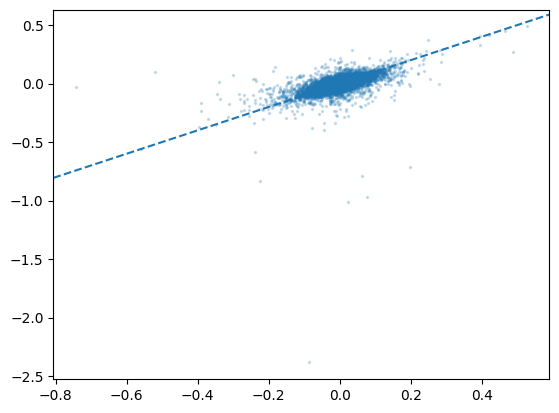

In [177]:
sample = pd.concat([
    np.log1p(ret_cc).stack(),
    np.log1p(ret_co.shift(1) + ret_oc).stack()
], axis=1).dropna().sample(50000)

plt.scatter(sample.iloc[:,0], sample.iloc[:,1], s=2, alpha=0.2)
plt.axline((0,0), slope=1, linestyle="--")
plt.show()